In [63]:
import numpy as np
import xtrack as xt
import matplotlib.pyplot as plt
from xsuite_optics_imperfections import find_elements

In [64]:
### Comments from Jorg
# You can find Z and H files for LEP3. So far I worked with 11f, the
# latest is 1101f (11.0.1). Not fully sure what the difference is. In case
# of doubt start with 11f.

# LEP3 has only 2 experiments (in the positions of ATLAS and CMS).

# Note that the arc bends are combined function magnets. Although the K1
# does not look large, integrated over a 3 bends between 2 quads, K1L is
# sizeable. That could be interesting wrt dipole alignment tolerances.
# Surely an interesting point to investigate the tolerances for such
# combined fct bends.

In [ ]:
line_file = '_fromJorg/LEP3_Z_11f.json'
line = xt.Line.from_json(line_file)

# gamma to kinetic energy in GeV # same as FCC-ee?
gamma = line.particle_ref.gamma0[0]
mass0_gev = line.particle_ref.mass0 * 1e-9
kinetic_energy = float((gamma - 1) * mass0_gev)
print(f'kinetic_energy = ',kinetic_energy, ' GeV')
tt = line.get_table()
tt.keys()

Loading line from dict:   0%|          | 0/8444 [00:00<?, ?it/s]

/home/tprebiba/miniforge3/envs/fcc-2025/lib/python3.12/site-packages/xtrack/beam_elements/elements.py:793: FutureWarning: `lag` (in degrees) is deprecated and will be removed in a future version. Please use `phase` (in radians) instead. If you see this warning while loading a saved line from a previous version of Xsuite, please regenerate the line with the current version to use phase instead of lag. Note that if both `lag` and `phase` are set, the effect is the sum of the two,  with `lag` converted to radians.  This deprecation is part of the interface cleanup in view of the 1.0 release.
  self.lag = lag


Done loading line from dict.           


/home/tprebiba/miniforge3/envs/fcc-2025/lib/python3.12/site-packages/xplt/hooks.py:31: RuntimeWarning: Failed to register formatters with pint: No module named 'pint'
  warnings.warn(f"Failed to register formatters with pint: {e}", RuntimeWarning)
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


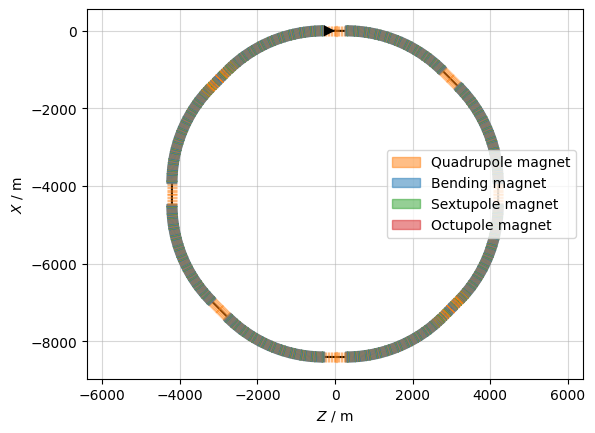

In [67]:
# check survey and plot using xplt
sv = line.survey()
sv.plot()

### Matching tune

Number of quads dependent on kqf2 304
Number of quads dependent on kqd1 440


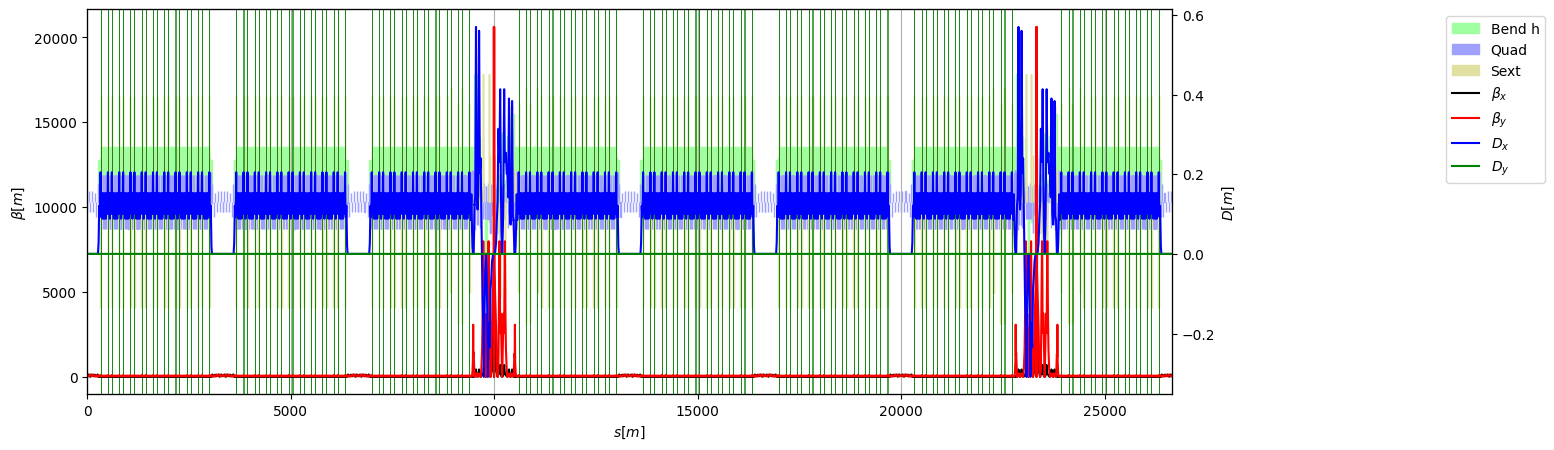

In [58]:
# Get all variables
#print(line.vars.get_independent_vars())
ttvar = line.vars.get_table()

var1list = list(line.vars['kqf2']._find_dependant_targets())[1::]
dependent_on_kqf2 = []
for el in var1list:
    if 'k1' in str(el):
        dependent_on_kqf2.append(str(str(el).split("'")[1]))
print('Number of quads dependent on kqf2', len(dependent_on_kqf2))

var1list = list(line.vars['kqd1']._find_dependant_targets())[1::]
dependent_on_kqd1 = []
for el in var1list:
    if 'k1' in str(el):
        dependent_on_kqd1.append(str(str(el).split("'")[1]))
print('Number of quads dependent on kqd1', len(dependent_on_kqd1))

tw = line.twiss()

f, ax = plt.subplots(1,1,figsize=(14,5))
tw.plot(ax=ax)
#ax.set_xlim(8000, 12000)
#ax.set_xlim(5000-200, 5000+200)
for q in dependent_on_kqf2:
    ax.axvline(x=tt.s[tt.name==q], color='green', linestyle='-', lw=0.5)
# for q in dependent_on_kqd1:
#    ax.axvline(x=tt.s[tt.name==q], color='red', linestyle='-', lw=0.5)


# opt_tune = line.match(
#     method='6d',
#     vary=[xt.VaryList(['kqf2', 'kqd1'], step=1e-8, tag='quad'),
#         ],
#     targets=[xt.TargetSet(qx=195.1662643101125, qy=87.2107959626699, tol=1e-5, tag='tune'),
#         ])

### Matching chroma

In [68]:
# Add chroma knobs, a la FCC-ee
line.vars['sf.k2n.chroma.knob'] = 1
line.vars['sd.k2n.chroma.knob'] = 1
for ii in tt.rows['sf[12]a.*'].name:
    if '_aper' not in ii:
        line.element_refs[ii].k2 = line.vars['sf.k2n.chroma.knob']*line.element_refs[ii].k2._expr
for ii in tt.rows['sd[12]a.*'].name:
    if '_aper' not in ii:
        line.element_refs[ii].k2 = line.vars['sd.k2n.chroma.knob']*line.element_refs[ii].k2._expr

In [60]:
tw0 = line.twiss()
print(tw0.qx, tw0.qy)
print(tw0.dqx, tw0.dqy)
print(tw0.rows['ip.*'].cols['betx bety'])

195.1662643101125 87.2107959626699
3.3141121799791375 2.316359236360689
TwissTable: 4 rows, 3 cols
name          betx          bety
ip:0     0.0999947   0.000500307
ip:1     0.0999947   0.000500307
ip:2     0.0999947   0.000500307
ip       0.0999947   0.000500307


In [69]:
# opt_chroma = line.match(
#     method='6d',
#     vary=[xt.VaryList(['sf.k2n.chroma.knob', 'sd.k2n.chroma.knob',], step=1e-3, tag='sext'),
#         ],
#     targets=[xt.TargetSet(dqx=5, dqy=4, tol=1e-2, tag='chrom'),
#         ])
# # tw0 = line.twiss()
# # print(tw0.qx, tw0.qy)
# # print(tw0.dqx, tw0.dqy)
# # print(tw0.rows['ip.*'].cols['betx bety'])

# Twiss

In [6]:
#line.twiss_default['method'] = '4d' # if no RF present, default is '6d
#line.twiss_default['group_compound_elements'] = True # to hide group "compound" elements
#line.twiss_default
tw = line.twiss()
print('Tune x, y = ', tw.qx, tw.qy)

Tune x, y =  195.1662643101125 87.2107959626699


(4800.0, 5200.0)

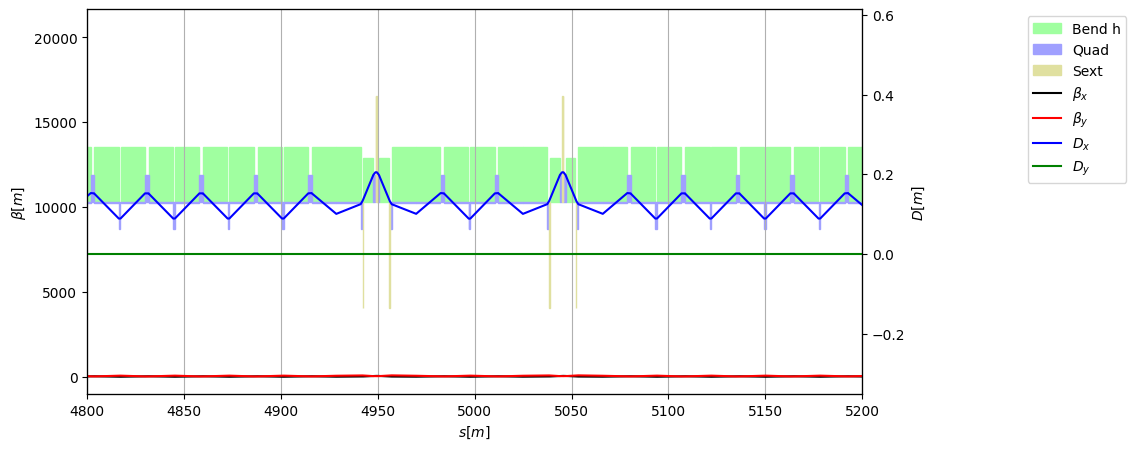

In [7]:
f, ax = plt.subplots(1,1,figsize=(10,5))
tw.plot(ax=ax)
#ax.set_xlim(8000, 12000)
ax.set_xlim(5000-200, 5000+200)
#for qa in ttqa.name:
#    if '.2' in qa:
#        print(qa)
#        ax.axvline(x=ttqa.s[ttqa.name==qa], color='black', linestyle='--', lw=2)

# Install markers at the IR boundaries

In [70]:
line2 = line.copy()

In [71]:
# Find IPs
C    = line2.get_length()
tt   = line2.get_table()
tta  = line2.get_table(attr=True)
ips = tt.rows['.*ip.*']
ip_names = ips.name[0::2]
ip_s = ips.s[0::2]
print(ip_s)
#ip_s = np.array([9994.59293139, 23320.76038856])   # or from your tt.rows[...] slice
d    = ip_s[1] - ip_s[0]
print(f'C          = {C:.6f} m')
print(f'IP spacing = {d:.6f} m')
print(f'C/2        = {C/2:.6f} m   ->  mismatch {d - C/2:+.6f} m')

[ 9994.59293139 23320.76038856]
C          = 26652.334914 m
IP spacing = 13326.167457 m
C/2        = 13326.167457 m   ->  mismatch -0.000000 m


In [72]:
# Find symmetry points
s_points = np.array([(ip_s[0] + k * C / 8) % C for k in range(8)])
s_points.sort()
print('eight symmetry points:')
for j, sp in enumerate(s_points):
    print(f'  {j}:  s = {sp:11.3f} m')

eight symmetry points:
  0:  s =    3331.509 m
  1:  s =    6663.051 m
  2:  s =    9994.593 m
  3:  s =   13326.135 m
  4:  s =   16657.677 m
  5:  s =   19989.219 m
  6:  s =   23320.760 m
  7:  s =   26652.302 m


In [73]:
# Find boundaries between straights and arcs
n_el   = len(line2.element_names)
s_el   = tta.s[:n_el]
len_el = tta.length[:n_el]
k0l_el = tta.k0l[:n_el]
is_bend = np.abs(k0l_el) > 1e-12
print(f'{is_bend.sum()} bending elements found')      # sanity check
s_bend_in  = s_el[is_bend]
s_bend_out = s_el[is_bend] + len_el[is_bend]
def bend_free_extent(s_c):
    """Distance from s_c to the first bend downstream / upstream."""
    d_fwd = (s_bend_in  - s_c) % C
    d_bwd = (s_c - s_bend_out) % C
    return d_bwd.min(), d_fwd.min()
MARGIN = 0.0    # m; positive value eats into the arc (dispersion suppressor),
                # negative value keeps the boundary strictly inside the straight
boundaries = []
print('\nIR extents:')
for i, s_c in enumerate(s_points, start=1):
    if i in [3, 7]: # these are the interaction points;
        back, fwd = 265.47*2+40, 265.54*2+40 # approximate and hardcoded; to be improved
    else:
        back, fwd = bend_free_extent(s_c)
        #back, fwd = 265.47, 265.54 # keep it fixed
    s_start = (s_c - back - MARGIN) % C
    s_end   = (s_c + fwd  + MARGIN) % C
    boundaries.append((f'ir{i}_start', s_start))
    boundaries.append((f'ir{i}_end',   s_end))
    print(f'  IR{i}:  s = {s_c:10.2f}   straight = {back+fwd:8.2f} m '
          f'({back:7.2f} back / {fwd:7.2f} fwd)')

1766 bending elements found

IR extents:
  IR1:  s =    3331.51   straight =   531.01 m ( 265.47 back /  265.54 fwd)
  IR2:  s =    6663.05   straight =   531.01 m ( 265.47 back /  265.54 fwd)
  IR3:  s =    9994.59   straight =  1142.02 m ( 570.94 back /  571.08 fwd)
  IR4:  s =   13326.13   straight =   531.01 m ( 265.47 back /  265.54 fwd)
  IR5:  s =   16657.68   straight =   531.01 m ( 265.47 back /  265.54 fwd)
  IR6:  s =   19989.22   straight =   531.01 m ( 265.47 back /  265.54 fwd)
  IR7:  s =   23320.76   straight =  1142.02 m ( 570.94 back /  571.08 fwd)
  IR8:  s =   26652.30   straight =   531.01 m ( 265.47 back /  265.54 fwd)


In [74]:
# Install markers at the boundaries
def nearest_element_index(s_target):
    i = int(np.searchsorted(s_el, s_target))
    i = int(np.clip(i, 1, n_el - 1))
    if abs(s_el[i] - s_target) > abs(s_el[i-1] - s_target):
        i -= 1
    return i

resolved = [(name, nearest_element_index(s)) for name, s in boundaries]

for name, idx in sorted(resolved, key=lambda x: -x[1]):
    line2.insert_element(index=idx, element=xt.Marker(), name=name)

print(line2.get_table().rows[r'ir\d+_(start|end)'])

LineTable: 16 rows, 13 cols
name                  s element_type isthick isreplica parent_name parent_type prototype ...
ir8_end         265.507 Marker         False     False None        None        None     
ir1_start       3066.03 Marker         False     False None        None        None     
ir1_end         3597.05 Marker         False     False None        None        None     
ir2_start       6397.58 Marker         False     False None        None        None     
ir2_end         6928.59 Marker         False     False None        None        None     
ir3_start       9423.63 Marker         False     False None        None        None     
ir3_end         10565.6 Marker         False     False None        None        None     
ir4_start       13060.7 Marker         False     False None        None        None     
ir4_end         13591.7 Marker         False     False None        None        None     
ir5_start       16392.2 Marker         False     False None        None       

/home/tprebiba/miniforge3/envs/fcc-2025/lib/python3.12/site-packages/xtrack/line.py:3435: FutureWarning: Line.insert_element is deprecated. Use Line.insert instead. This deprecation is part of the interface cleanup in view of the 1.0 release.
  warn('Line.insert_element is deprecated. Use Line.insert instead.'


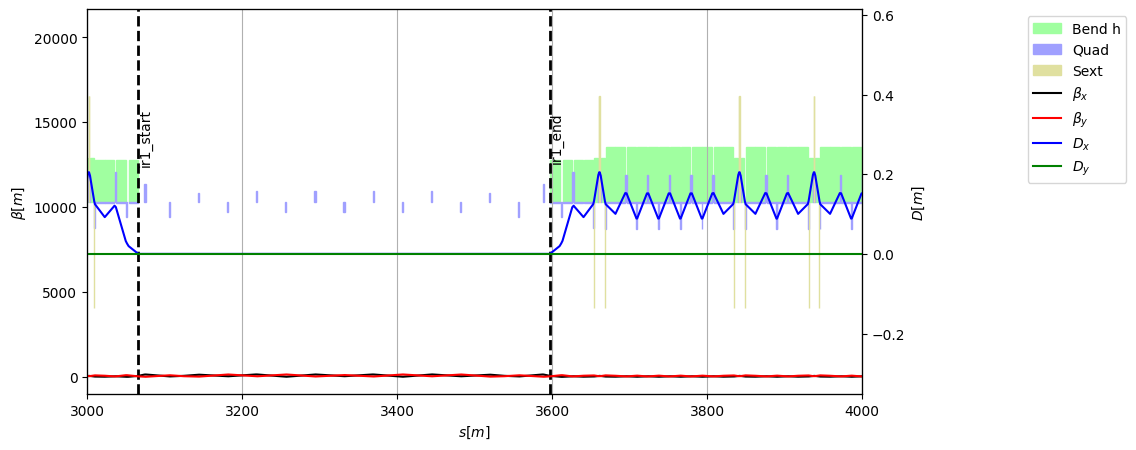

In [75]:
tt = line2.get_table()
tw = line2.twiss()
f, ax = plt.subplots(1,1,figsize=(10,5))
tw.plot(ax=ax)
xlim1, xlim2 = 3000, 4000 # a technical insertion (no dipoles)
#xlim1, xlim2 = 9000, 11000 # an interaction region (some dipoles)
#xlim1, xlim2 = 22000, 24000 # an interaction region (some dipoles)
#xlim1, xlim2 = 2000, 2100 # an interaction region (some dipoles)
#xlim1, xlim2 = 0, 27000
ax.set_xlim(xlim1, xlim2) # a technical insertion (no dipoles)
for irbounary, irname in zip(tt.rows['ir.*'].s, tt.rows['ir.*'].name):
    ax.axvline(x=irbounary, color='black', linestyle='--', lw=2)
    if xlim1 < irbounary < xlim2:
        ax.text(irbounary+0.1, 0.5, f'{irname}', rotation=90, verticalalignment='center', fontsize=10)

In [76]:
# Hardcoded for now; to be improved later
markers_per_arc = [
    ('ir8_end', 'ir1_start'),
    ('ir1_end', 'ir2_start'),
    ('ir2_end', 'ir3_start'),
    ('ir3_end', 'ir4_start'),
    ('ir4_end', 'ir5_start'),
    ('ir5_end', 'ir6_start'),
    ('ir6_end', 'ir7_start'),
    ('ir7_end', 'ir8_start'),
]
markers_per_tr = [
    ('ir1_start', 'ir1_end'),
    ('ir2_start', 'ir2_end'),
    ('ir4_start', 'ir4_end'),
    ('ir5_start', 'ir5_end'),
    ('ir6_start', 'ir6_end'),
    ('ir8_start', 'ir8_end'),
]
markers_per_ff = [
    ('ir3_start', 'ir3_end'),
    ('ir7_start', 'ir7_end'),
]

all_arc_bends = find_elements(tt, marker_pairs = markers_per_arc)
all_arc_bends = all_arc_bends.rows[(all_arc_bends.element_type == 'Bend') | (all_arc_bends.element_type == 'RBend')]
all_arc_quads = find_elements(tt, marker_pairs = markers_per_arc, element_type = 'Quadrupole')
all_arc_sexts = find_elements(tt, marker_pairs = markers_per_arc, element_type = 'Sextupole')

all_tr_bends = find_elements(tt, marker_pairs = markers_per_tr, element_type='Bend')
#all_tr_bends = all_tr_bends.rows[(all_arc_bends.element_type == 'Bend') | (all_arc_bends.element_type == 'RBend')]
all_tr_quads = find_elements(tt, marker_pairs = markers_per_tr, element_type = 'Quadrupole')
all_tr_sexts = find_elements(tt, marker_pairs = markers_per_tr, element_type = 'Sextupole')

all_ff_bends = find_elements(tt, marker_pairs = markers_per_ff)
all_ff_bends = all_ff_bends.rows[(all_ff_bends.element_type == 'Bend') | (all_ff_bends.element_type == 'RBend')]
all_ff_quads_but_fd = find_elements(tt, marker_pairs = markers_per_ff, element_type = 'Quadrupole', except_pattern='q[f|d][0|1][a|b|c][r|l]')
all_fd_quads = find_elements(tt, pattern='q[f|d][0|1][a|b|c][r|l]',element_type = 'Quadrupole')
all_ff_sexts = find_elements(tt, marker_pairs = markers_per_ff, element_type = 'Sextupole')

print(f'Found in arcs: {len(all_arc_bends.name)} dipoles, {len(all_arc_quads.name)} quads, {len(all_arc_sexts.name)} sextupoles.')
print(f'Found in technical regions: {len(all_tr_bends.name)} dipoles, {len(all_tr_quads.name)} quads, {len(all_tr_sexts.name)} sextupoles.')
print(f'Found in final focusing: {len(all_ff_bends.name)} dipoles, {len(all_fd_quads.name)} FD quads and {len(all_ff_quads_but_fd.name)} other quads, {len(all_ff_sexts.name)} sextupoles.')

Found in arcs: 1680 dipoles, 1592 quads, 608 sextupoles.
Found in technical regions: 0 dipoles, 96 quads, 0 sextupoles.
Found in final focusing: 86 dipoles, 20 FD quads and 164 other quads, 88 sextupoles.


/eos/home-t/tprebiba/EPFL/14_LEP3/xsuite_optics_imperfections.py:97: UserWarning: Warning: No elements matched.
  warnings.warn("Warning: No elements matched.")


# Install BPMs (markers) at every quadrupole (straights and IRs)

In [77]:
env = line2.env
tt = line2.get_table()
inserts = []
for nm in list(all_arc_quads.name) + list(all_tr_quads.name) + list(all_ff_quads_but_fd.name) + list(all_fd_quads.name):
    if 'qd0b' in nm or 'qd0c' in nm or 'qf1b' in nm:
        print(f'Skipping BPM insertion at {nm} (QD0 quadrupole)')
        continue
    bpm_name = f'bpm_{nm}'
    env.new(bpm_name, xt.Marker)
    s_quad = tt['s_start', nm]
    inserts.append(env.place(bpm_name, at=s_quad))
print(f'Inserted {len(inserts)} BPMs at quadrupoles')
line2.insert(inserts)
tt = line2.get_table()   # refresh after insertion

Skipping BPM insertion at qf1bl (QD0 quadrupole)
Skipping BPM insertion at qd0cl (QD0 quadrupole)
Skipping BPM insertion at qd0bl (QD0 quadrupole)
Skipping BPM insertion at qd0br:0 (QD0 quadrupole)
Skipping BPM insertion at qd0cr:0 (QD0 quadrupole)
Skipping BPM insertion at qf1br:0 (QD0 quadrupole)
Skipping BPM insertion at qf1bl:0 (QD0 quadrupole)
Skipping BPM insertion at qd0cl:0 (QD0 quadrupole)
Skipping BPM insertion at qd0bl:0 (QD0 quadrupole)
Skipping BPM insertion at qd0br (QD0 quadrupole)
Skipping BPM insertion at qd0cr (QD0 quadrupole)
Skipping BPM insertion at qf1br (QD0 quadrupole)
Inserted 1860 BPMs at quadrupoles


Slicing line:   0%|          | 0/8460 [00:00<?, ?it/s]

# Install hcorr and vcorr at every quadrupole

In [78]:
qf_quads = []
qd_quads = []
#for nm in all_arc_quads:
for nm in list(all_arc_quads.name) + list(all_tr_quads.name) + list(all_ff_quads_but_fd.name) + list(all_fd_quads.name):
    k1 = line2[nm].k1
    if k1 > 0:
        qf_quads.append(nm)
    else:
        qd_quads.append(nm)
print(f'{len(qf_quads)} QF quads  ->  horizontal correctors')
print(f'{len(qd_quads)} QD quads  ->  vertical correctors')

env = line2.env
tt = line2.get_table()

inserts = []
hcor_names = []
vcor_names = []

for nm in qf_quads+qd_quads:
    corr_name = f'hcor_{nm}'
    if corr_name in line2.element_dict:
        continue
    line2.vars[f'knl_{nm}'] = 0.0
    env.new(corr_name, xt.Multipole, knl=[0.])
    inserts.append(env.place(corr_name, at=tt['s_start', nm]))
    hcor_names.append(corr_name)

for nm in qd_quads+qf_quads:
    corr_name = f'vcor_{nm}'
    if corr_name in line2.element_dict:
        continue
    line2.vars[f'ksl_{nm}'] = 0.0
    env.new(corr_name, xt.Multipole, ksl=[0.])
    inserts.append(env.place(corr_name, at=tt['s_start', nm]))
    vcor_names.append(corr_name)

line2.insert(inserts)

for nm in qf_quads:
    line2.element_refs[f'hcor_{nm}'].knl[0] = line2.vars[f'knl_{nm}']

for nm in qd_quads:
    line2.element_refs[f'ksl_{nm}'.replace('ksl_', 'vcor_')].ksl[0] = line2.vars[f'ksl_{nm}']

tt = line2.get_table()
tthcor = tt.rows['hcor_.*']
ttvcor = tt.rows['vcor_.*']
print(f'installed {len(tthcor)} H correctors, {len(ttvcor)} V correctors')

980 QF quads  ->  horizontal correctors
892 QD quads  ->  vertical correctors


Slicing line:   0%|          | 0/10320 [00:00<?, ?it/s]

installed 1872 H correctors, 1872 V correctors


In [79]:
line2.to_json('100_lines_with_BPM_correctors/LEP3_Z_11f_wMarkers_wBPMs_wCorr.json')